In [1]:
!pip install grad-cam
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 113.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=5cd2c399c00a1a4ba40eaac26c0e208307702293e2e3025c323e7f4aa599def9
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 20.06 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.


In [2]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Aktif Cihaz: {device} ")

Aktif Cihaz: cuda 


In [3]:

def map_to_full_path(subpath, path_lookup_dict):
    parts = subpath.split('/')
    if len(parts) >= 2:
        key = os.path.join(parts[-2], parts[-1])
        return path_lookup_dict.get(key, None)
    return None

# --- Configuration & Paths ---
test_csv_path = "data/splits/test_split.csv"
image_dir = "PlantVillage-Dataset/raw/color"

if not os.path.exists(test_csv_path):
    raise FileNotFoundError(f"Critical Error: '{test_csv_path}' not found.")

# --- Load & Clean Metadata ---
test_df = pd.read_csv(test_csv_path)
test_df.columns = [c.strip() for c in test_df.columns]
test_df['clean_subpath'] = test_df['text'].astype(str).str.strip()

# --- File System Indexing & Alignment ---
all_image_paths = (
    glob.glob(os.path.join(image_dir, "**/*.JPG"), recursive=True) +
    glob.glob(os.path.join(image_dir, "**/*.png"), recursive=True)
)

path_lookup = {
    os.path.join(p.split(os.sep)[-2], p.split(os.sep)[-1]): p
    for p in all_image_paths
}

test_df['full_path'] = test_df['clean_subpath'].apply(lambda x: map_to_full_path(x, path_lookup))
test_df = test_df.dropna(subset=['full_path']).reset_index(drop=True)

# --- Label Generation & Mapping ---
test_df['multiclass_name'] = test_df['clean_subpath'].apply(lambda x: x.split('/')[-2] if '/' in x else '')
class_names = sorted(test_df['multiclass_name'].unique().tolist())
num_classes = len(class_names)

class_to_idx = {name: idx for idx, name in enumerate(class_names)}
test_df['label'] = test_df['multiclass_name'].apply(lambda x: class_to_idx.get(x, 0))

print(f"Number of classes: {num_classes}")
print(f"Number of test images: {len(test_df)}")

Number of classes: 38
Number of test images: 16842


In [4]:
# --- Data Transformations ---
multiclass_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- Custom Dataset Class ---
class PlantDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['full_path']
        label = self.df.iloc[idx]['label']

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# --- DataLoader Initialization ---
test_loader = DataLoader(PlantDataset(test_df, transform=multiclass_transform), batch_size=32, shuffle=False)
print("=== SIZINTISIZ TEST LOADER AYAĞA KALDIRILDI ===")

=== SIZINTISIZ TEST LOADER AYAĞA KALDIRILDI ===


In [5]:
# --- Model Architecture Definition ---
class PlantMobileNetModel(nn.Module):
    def __init__(self, num_classes=38):
        super(PlantMobileNetModel, self).__init__()
        try:
            self.backbone = models.mobilenet_v2(weights=models.MobileNetV2_Weights.DEFAULT)
        except AttributeError:
            self.backbone = models.mobilenet_v2(pretrained=True)

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [6]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- Plotting Style Configuration ---
def set_project_plot_style():
    plt.style.use('ggplot')
    plt.rcParams['figure.dpi'] = 100
    plt.rcParams['font.size'] = 10
    sns.set_palette("viridis")

# --- Model Evaluation & Logging ---
def evaluate_model(true_labels, pred_labels, class_names):
    report = classification_report(true_labels, pred_labels, target_names=class_names, output_dict=True)
    print(classification_report(true_labels, pred_labels, target_names=class_names))
    return report

# --- Save Evaluation Metrics ---
def save_results(sonuclar):
    os.makedirs('artifacts/reports/', exist_ok=True)
    file_path = 'artifacts/reports/evaluation_results.json'
    with open(file_path, 'w') as f:
        json.dump(sonuclar, f, indent=4)
    print(f"Metrics successfully saved to: {file_path}")

# --- Confusion Matrix Visualization ---
def plot_confusion_matrix(y_true, y_pred, class_names, split_name="Test", is_binary=False):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8) if is_binary else (18, 14))

    sns.heatmap(cm, annot=is_binary, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

    title_suffix = "Binary" if is_binary else "Multiclass"
    plt.title(f"Confusion Matrix ({title_suffix}) - {split_name}", fontsize=14)
    plt.xticks(rotation=90 if not is_binary else 0)
    plt.yticks(rotation=0)

    os.makedirs('artifacts/figures/', exist_ok=True)
    filename = f"cm_{split_name.lower()}_binary.png" if is_binary else f"cm_{split_name.lower()}.png"
    plt.savefig(f'artifacts/figures/{filename}', dpi=300, bbox_inches='tight')
    plt.show()

# --- Prediction Gallery Visualization ---
def plot_prediction_gallery(images, true_labels, pred_labels, class_names, num_images=5):
    plt.figure(figsize=(15, 3))
    for i in range(min(num_images, len(images))):
        plt.subplot(1, num_images, i + 1)

        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        plt.imshow(img)
        title_color = "green" if true_labels[i] == pred_labels[i] else "red"
        plt.title(f"G: {class_names[true_labels[i]]}\nP: {class_names[pred_labels[i]]}", fontsize=8, color=title_color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- Grad-CAM Error Visualization ---
def generate_grad_cam_visualization(model, input_tensor, rgb_img, target_layer, filename="grad_cam"):
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image

    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(np.argmax(model(input_tensor).detach().cpu().numpy()))]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(18, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title("Failure Case - Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(grayscale_cam, cmap='jet')
    plt.title("Heatmap")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(visualization)
    plt.title("Grad-CAM Overlay")
    plt.axis('off')

    os.makedirs('artifacts/figures/', exist_ok=True)
    plt.savefig(f'artifacts/figures/{filename}.png', dpi=300, bbox_inches='tight')
    plt.show()

=== Evaluation Pipeline Started ===
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 13.6M/13.6M [00:00<00:00, 202MB/s]
100%|██████████| 527/527 [00:40<00:00, 13.10it/s]


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.93      0.94       183
                                 Apple___Black_rot       0.99      0.96      0.98       226
                          Apple___Cedar_apple_rust       0.39      1.00      0.56        81
                                   Apple___healthy       0.99      0.91      0.95       536
                               Blueberry___healthy       0.98      0.99      0.99       475
          Cherry_(including_sour)___Powdery_mildew       0.98      0.89      0.93       308
                 Cherry_(including_sour)___healthy       0.98      0.98      0.98       293
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       1.00      0.63      0.77       135
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       366
               Corn_(maize)___Northern_Leaf_Blight       0.83      1.00      0.

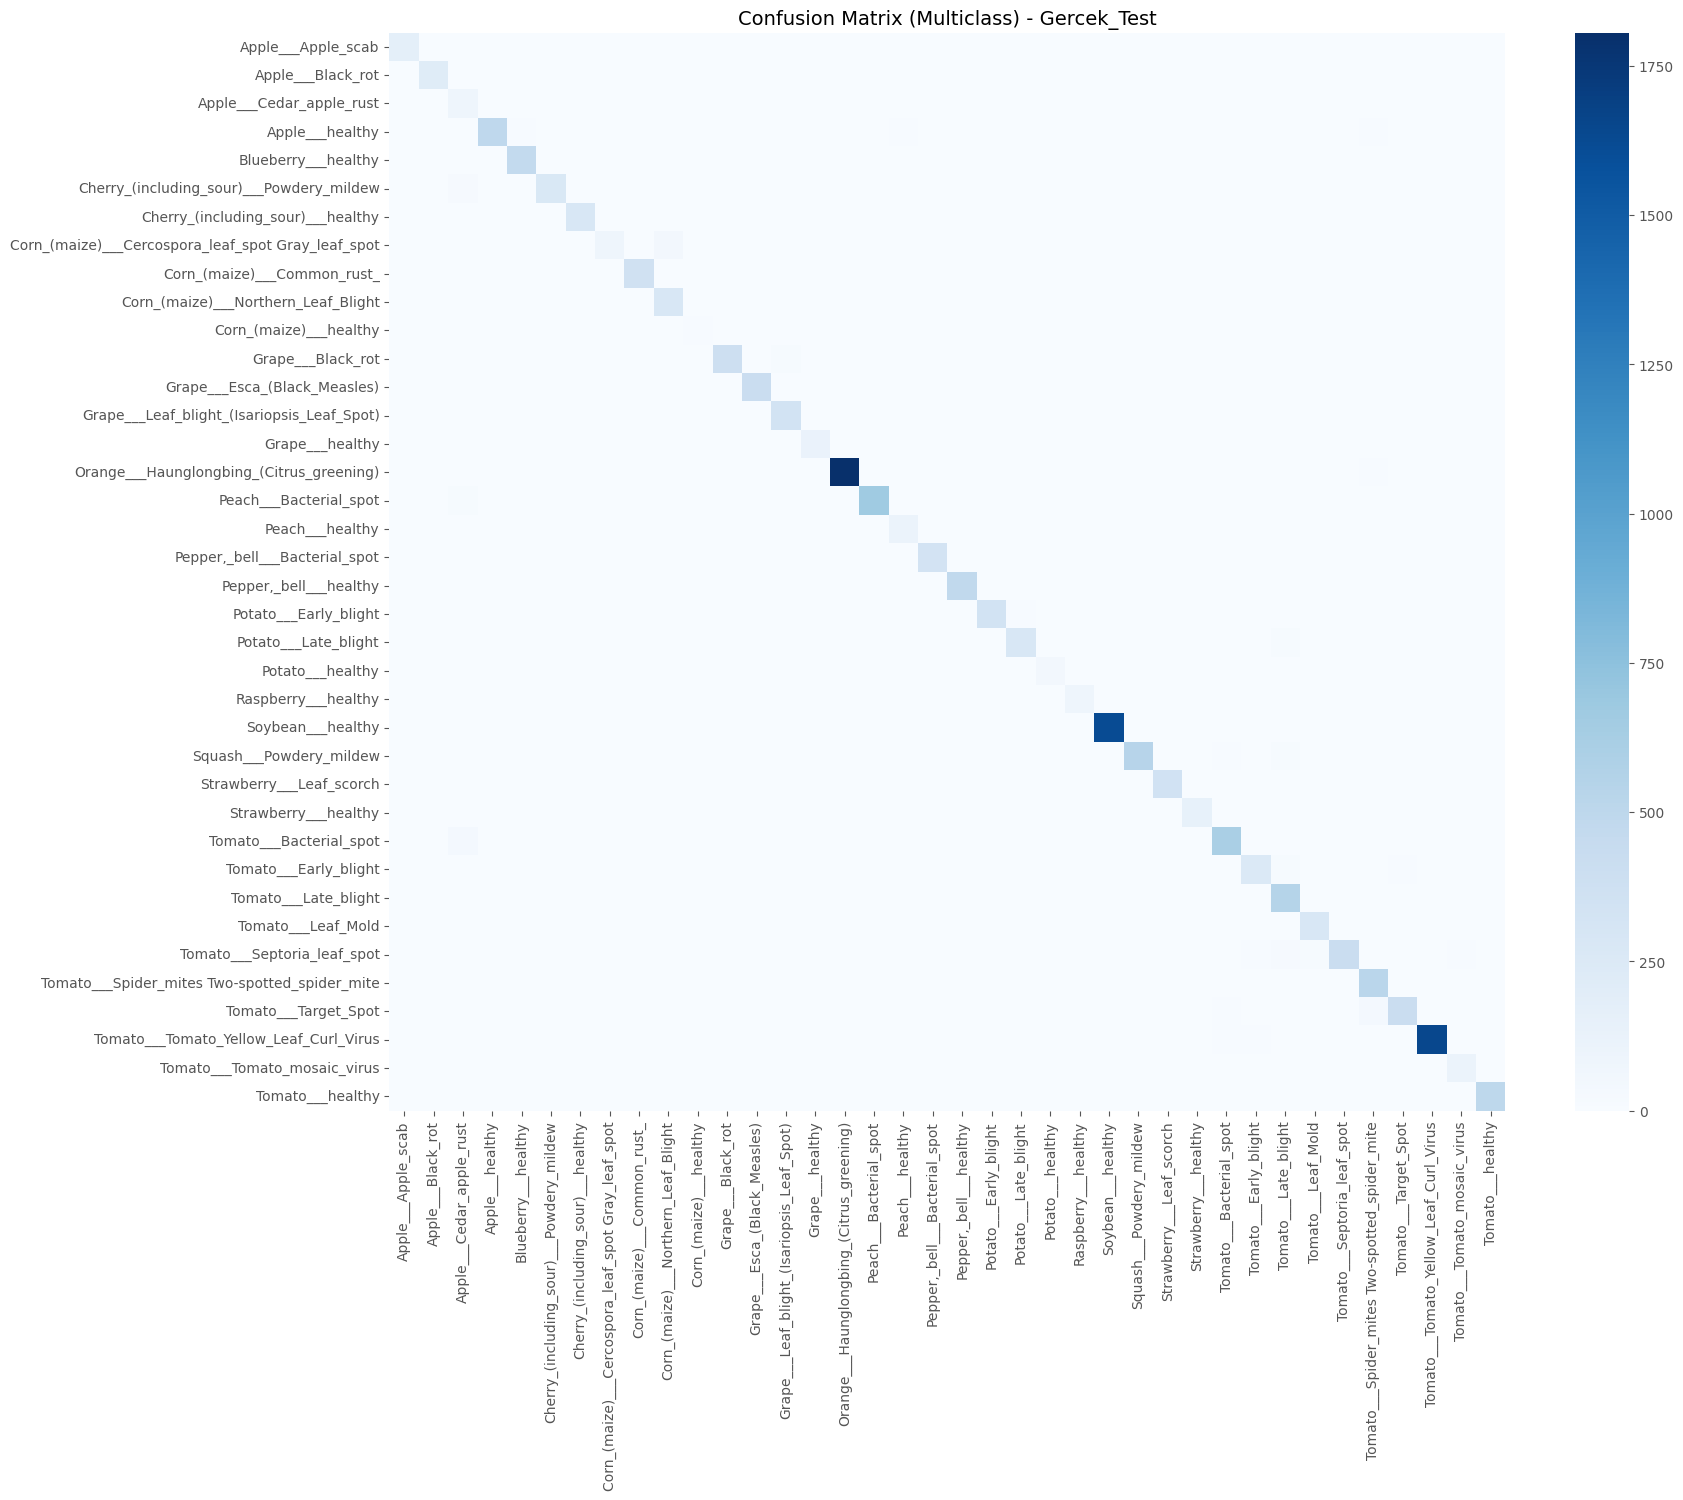


--- Binary Classification Report (Healthy vs Diseased) ---
              precision    recall  f1-score   support

    Sağlıklı       1.00      0.99      0.99      4476
  Hastalıklı       1.00      1.00      1.00     12366

    accuracy                           1.00     16842
   macro avg       1.00      0.99      0.99     16842
weighted avg       1.00      1.00      1.00     16842



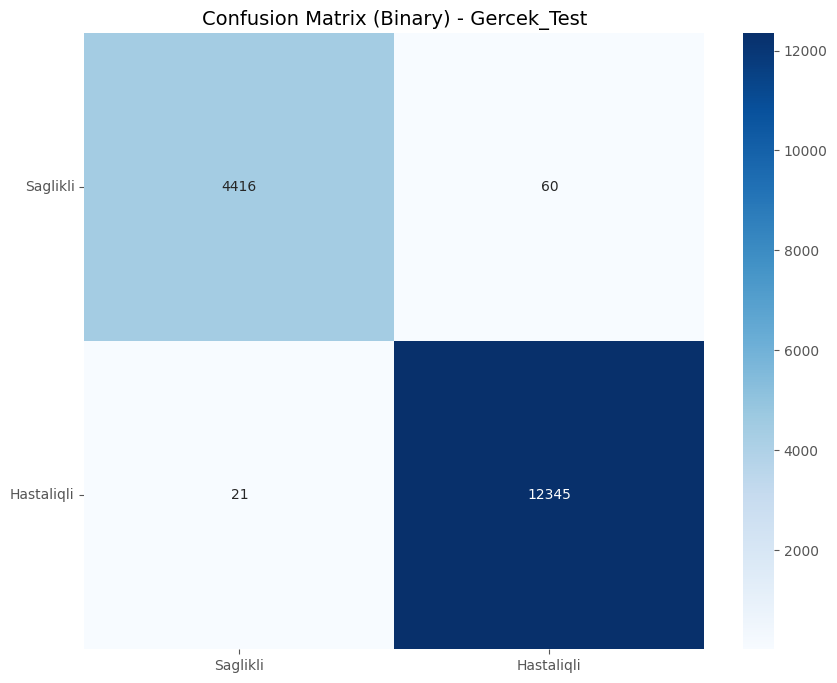


--- Prediction Gallery ---


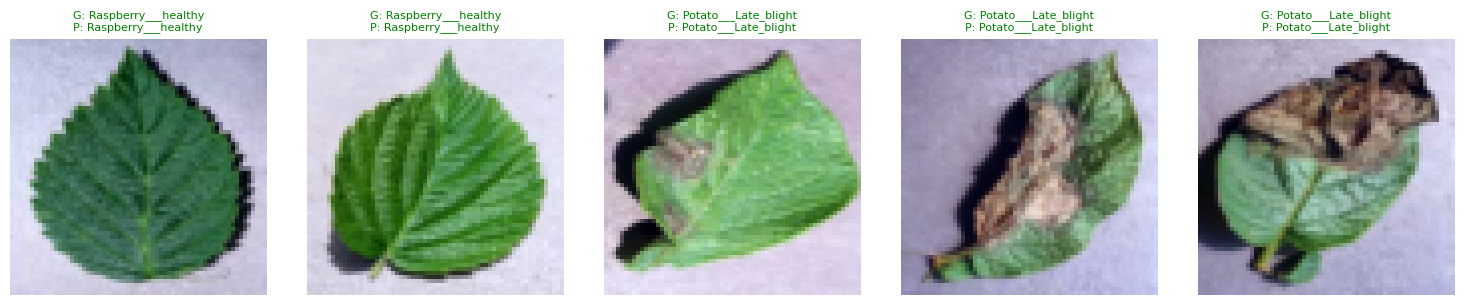


--- Error Analysis Focus ---
True Class: Potato___Late_blight | Predicted Class: Tomato___Late_blight


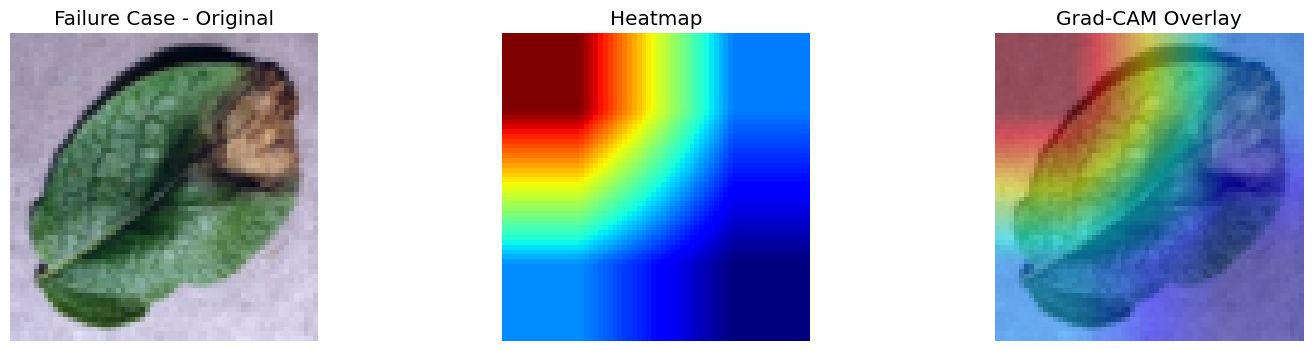


=== Evaluation Pipeline Successfully Completed ===


In [7]:
from tqdm import tqdm
import torch

# --- Evaluation Setup ---
set_project_plot_style()
print("=== Evaluation Pipeline Started ===")

eval_model = PlantMobileNetModel(num_classes=num_classes).to(device)
eval_model.load_state_dict(torch.load("models/checkpoints/best_model.pth", map_location=device))
eval_model.eval()

# --- Metrics Containers ---
all_preds, all_labels = [], []
gallery_images, gallery_trues, gallery_preds = [], [], []

first_wrong_image = None
first_wrong_true_label = None
first_wrong_pred_label = None

# --- Inference Loop ---
with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images_dev = images.to(device)
        outputs = eval_model(images_dev)
        _, predicted = torch.max(outputs, 1)

        preds_np = predicted.cpu().numpy()
        labels_np = labels.cpu().numpy()

        all_preds.extend(preds_np)
        all_labels.extend(labels_np)

        if len(gallery_images) < 5:
            gallery_images.append(images[0])
            gallery_trues.append(labels_np[0])
            gallery_preds.append(preds_np[0])

        if first_wrong_image is None:
            for idx in range(len(labels_np)):
                if labels_np[idx] != preds_np[idx]:
                    first_wrong_image = images[idx]
                    first_wrong_true_label = labels_np[idx]
                    first_wrong_pred_label = preds_np[idx]
                    break

# --- Multiclass Evaluation & Reporting ---
rapor_sonuc = evaluate_model(all_labels, all_preds, class_names)
save_results(rapor_sonuc)
plot_confusion_matrix(all_labels, all_preds, class_names, split_name="Gercek_Test", is_binary=False)

# --- Binary Evaluation (Healthy vs Diseased) ---
binary_true = [0 if "healthy" in class_names[l].lower() else 1 for l in all_labels]
binary_pred = [0 if "healthy" in class_names[p].lower() else 1 for p in all_preds]

print("\n--- Binary Classification Report (Healthy vs Diseased) ---")
print(classification_report(binary_true, binary_pred, target_names=["Sağlıklı", "Hastalıklı"]))
plot_confusion_matrix(binary_true, binary_pred, ["Saglikli", "Hastaliqli"], split_name="Gercek_Test", is_binary=True)

# --- Visualization & Error Analysis ---
print("\n--- Prediction Gallery ---")
plot_prediction_gallery(gallery_images, gallery_trues, gallery_preds, class_names)

if first_wrong_image is not None:
    print(f"\n--- Error Analysis Focus ---")
    print(f"True Class: {class_names[first_wrong_true_label]} | Predicted Class: {class_names[first_wrong_pred_label]}")

    input_tensor = first_wrong_image.unsqueeze(0).to(device)
    np_img = first_wrong_image.permute(1, 2, 0).numpy()
    np_img = (np_img - np_img.min()) / (np_img.max() - np_img.min())

    generate_grad_cam_visualization(
        model=eval_model, input_tensor=input_tensor, rgb_img=np_img,
        target_layer=eval_model.backbone.features[-1], filename="failure_case_gradcam"
    )

print("\n=== Evaluation Pipeline Successfully Completed ===")